# Demo: Salad Ingredient Detection

This notebook processes all images from the `imgs_salad` folder and detects the ingredients present in each one.

Ingredients are extracted from filenames and detected using SAM3 with simplified prompts:
- "egg" for hard_boiled_egg
- "steak" for caramelized_garlic_steak
- "salmon" for miso_glazed_steelhead
- Other ingredients keep their original names


In [9]:
import cv2
import numpy as np
from pathlib import Path
from datetime import datetime
from openfilter.filter_runtime.filter import Frame
from filter_sam3_detector.filter import FilterSAM3Detector
import matplotlib.pyplot as plt
import re
from collections import defaultdict


## Configuration


In [10]:
# Configuration
imgs_folder = Path("imgs_salad")
confidence_threshold = 0.2  # Minimum confidence threshold for SAM3 detector
min_score_filter = 0.3  # Minimum score to keep in final results

# Map ingredient names from filenames to detection prompts
INGREDIENT_PROMPT_MAPPING = {
    "hard_boiled_egg": "egg",
    "caramelized_garlic_steak": "steak",
    "miso_glazed_steelhead": "salmon",
    "miso_steelhead": "salmon",
    "blackened_chicken": "blackened_chicken",
    "roasted_chicken": "roasted_chicken",
    "chicken": "roasted_chicken",
    "roasted_tofu": "roasted_tofu",
    "warm_portobello_mix": "warm_portobello_mix",
    "avocado": "avocado",
}

# All possible ingredients
ALL_INGREDIENTS = [
    "avocado",
    "blackened_chicken",
    "caramelized_garlic_steak",
    "hard_boiled_egg",
    "miso_glazed_steelhead",
    "roasted_chicken",
    "roasted_tofu",
    "warm_portobello_mix",
]

print(f"Images folder: {imgs_folder}")
print(f"Confidence threshold: {confidence_threshold}")
print(f"Min score filter: {min_score_filter}")
print(f"\nIngredient prompt mapping:")
for key, value in INGREDIENT_PROMPT_MAPPING.items():
    print(f"  {key} -> '{value}'")


Images folder: imgs_salad
Confidence threshold: 0.2
Min score filter: 0.3

Ingredient prompt mapping:
  hard_boiled_egg -> 'egg'
  caramelized_garlic_steak -> 'steak'
  miso_glazed_steelhead -> 'salmon'
  miso_steelhead -> 'salmon'
  blackened_chicken -> 'blackened_chicken'
  roasted_chicken -> 'roasted_chicken'
  chicken -> 'roasted_chicken'
  roasted_tofu -> 'roasted_tofu'
  warm_portobello_mix -> 'warm_portobello_mix'
  avocado -> 'avocado'


## Extract Ingredients from Filenames


In [11]:
def extract_ingredients_from_filename(filename):
    """Extract ingredient names from image filename."""
    # Remove extension and convert to lowercase
    name = filename.stem.lower()
    
    # Replace underscores and spaces with underscores for consistency
    name = name.replace(" ", "_")
    
    found_ingredients = []
    found_prompts = set()
    
    # Check for specific ingredients first (more specific before general)
    # Order matters: check longer/more specific names first
    
    # Check for blackened_chicken (must check before roasted_chicken)
    if "blackened_chicken" in name or ("blackened" in name and "chicken" in name):
        found_ingredients.append("blackened_chicken")
        found_prompts.add("blackened_chicken")
    
    # Check for roasted_chicken (only if blackened_chicken not found)
    elif "roasted_chicken" in name or ("chicken" in name and "blackened" not in name):
        found_ingredients.append("roasted_chicken")
        found_prompts.add("roasted_chicken")
    
    # Check for miso_glazed_steelhead or miso_steelhead
    if "miso_glazed_steelhead" in name or "miso_steelhead" in name or ("miso" in name and "steelhead" in name):
        found_ingredients.append("miso_glazed_steelhead")
        found_prompts.add("salmon")
    
    # Check for hard_boiled_egg
    if "hard_boiled_egg" in name or "egg" in name:
        found_ingredients.append("hard_boiled_egg")
        found_prompts.add("egg")
    
    # Check for caramelized_garlic_steak
    if "caramelized_garlic_steak" in name or ("steak" in name and "miso" not in name):
        found_ingredients.append("caramelized_garlic_steak")
        found_prompts.add("steak")
    
    # Check for avocado
    if "avocado" in name:
        found_ingredients.append("avocado")
        found_prompts.add("avocado")
    
    # Check for roasted_tofu
    if "roasted_tofu" in name or ("tofu" in name and "roasted" in name):
        found_ingredients.append("roasted_tofu")
        found_prompts.add("roasted_tofu")
    
    # Check for warm_portobello_mix
    if "warm_portobello_mix" in name or ("portobello" in name and "warm" in name):
        found_ingredients.append("warm_portobello_mix")
        found_prompts.add("warm_portobello_mix")
    
    return found_ingredients, list(found_prompts)

# Get all image files
image_files = sorted(list(imgs_folder.glob("*.png")))
print(f"Found {len(image_files)} images\n")

# Extract ingredients from each filename
all_image_data = []
for img_path in image_files:
    ingredients, prompts = extract_ingredients_from_filename(img_path)
    all_image_data.append({
        "path": img_path,
        "ingredients": ingredients,
        "prompts": prompts
    })

# Select 5 images, trying to get one of each ingredient
# Priority: get images with unique primary ingredients
selected_image_data = []
seen_ingredients = set()
max_images = 5

# First pass: try to get one image per unique ingredient
for img_data in all_image_data:
    if len(selected_image_data) >= max_images:
        break
    
    # Get primary ingredient (first one)
    primary_ingredient = img_data["ingredients"][0] if img_data["ingredients"] else None
    
    # If we haven't seen this ingredient yet, add it
    if primary_ingredient and primary_ingredient not in seen_ingredients:
        selected_image_data.append(img_data)
        seen_ingredients.add(primary_ingredient)
        print(f"Selected: {img_data['path'].name}")
        print(f"  Ingredients: {img_data['ingredients']}")
        print(f"  Detection prompts: {img_data['prompts']}\n")

# If we still need more images, fill with any remaining
for img_data in all_image_data:
    if len(selected_image_data) >= max_images:
        break
    if img_data not in selected_image_data:
        selected_image_data.append(img_data)
        print(f"Selected (fill): {img_data['path'].name}")
        print(f"  Ingredients: {img_data['ingredients']}")
        print(f"  Detection prompts: {img_data['prompts']}\n")

image_data = selected_image_data
print(f"\nTotal selected for processing: {len(image_data)} images")


Found 29 images

Selected: avocado blackened_chicken.png
  Ingredients: ['blackened_chicken', 'avocado']
  Detection prompts: ['avocado', 'blackened_chicken']

Selected: chicken1.png
  Ingredients: ['roasted_chicken']
  Detection prompts: ['roasted_chicken']

Selected: miso_steelhead avocado.png
  Ingredients: ['miso_glazed_steelhead', 'avocado']
  Detection prompts: ['avocado', 'salmon']

Selected: tofu avocado.png
  Ingredients: ['avocado']
  Detection prompts: ['avocado']

Selected (fill): avocado blackened_chicken2.png
  Ingredients: ['blackened_chicken', 'avocado']
  Detection prompts: ['avocado', 'blackened_chicken']


Total selected for processing: 5 images


## Initialize SAM3 Detector


In [12]:
# Initialize detector (will update prompt for each object)
detector = FilterSAM3Detector({
    "text_prompt": "avocado",  # Initial prompt, will be updated
    "confidence_threshold": confidence_threshold,
    "device": "cuda",
    "visualize": False,
    "output_label": "detections",
})

detector.setup(detector.config)
print("SAM3 Detector initialized successfully!")


2025-12-29 11:34:19.019 1864961 INFO     [Filter] Raw subject data export is DISABLED (set OPENLINEAGE_EXPORT_RAW_DATA=true to enable)
2025-12-29 11:34:19.023 1864961 INFO     FilterSAM3Detector(config={'text_prompt': 'avocado', 'confidence_threshold': 0.2, 'device': 'cuda', 'visualize': False, 'output_label': 'detections', 'id': 'FilterSAM3Detector-yHk0xB'})
2025-12-29 11:34:19.026 1864961 INFO     ==========================================
2025-12-29 11:34:19.029 1864961 INFO     FilterSAM3Detector setup: {'text_prompt': 'avocado', 'confidence_threshold': 0.2, 'device': 'cuda', 'visualize': False, 'output_label': 'detections', 'id': 'FilterSAM3Detector-yHk0xB'}
2025-12-29 11:34:19.032 1864961 INFO     ==========================================
2025-12-29 11:34:19.035 1864961 INFO     Using device: cuda
2025-12-29 11:34:19.037 1864961 INFO     Loading SAM3 model on device: cuda
2025-12-29 11:34:19.040 1864961 INFO     Found BPE file at: /home/leandrobmarinho/datasets/filter-sam3-detec

SAM3 Detector initialized successfully!


## Process All Images


In [13]:
def process_image_for_detection(img_path, prompts_to_detect):
    """Process a single image and detect all specified ingredients."""
    # Load image
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        print(f"Warning: Could not load image: {img_path}")
        return None, []
    
    # Resize if needed (for consistency)
    img_bgr = cv2.resize(img_bgr, (1280, 720))
    
    # Process each object type separately
    all_detections = []
    
    for prompt in prompts_to_detect:
        # Update detector prompt for this object
        detector.cfg.text_prompt = prompt
        detector.text_prompt = prompt
        
        # Create Frame object
        frame = Frame(image=img_bgr, format="BGR")
        frames_dict = {"frames": frame}
        
        # Run detection
        detected = detector.process(frames_dict)
        
        # Extract detections and label them
        if detected:
            for topic, frame in detected.items():
                dets = frame.data.get('meta', {}).get('detections', [])
                for det in dets:
                    labeled_det = det.copy()
                    labeled_det['label'] = prompt
                    all_detections.append(labeled_det)
                break
    
    # Filter detections by minimum score
    filtered_detections = [det for det in all_detections if det.get('score', 0.0) >= min_score_filter]
    
    return img_bgr, filtered_detections

# Process all images
results = []

print("Processing all images...\n")
for img_data in image_data:
    img_path = img_data["path"]
    prompts = img_data["prompts"]
    
    print(f"Processing: {img_path.name}")
    print(f"  Looking for: {prompts}")
    
    img_bgr, detections = process_image_for_detection(img_path, prompts)
    
    if img_bgr is not None:
        detected_labels = set(det.get('label', 'unknown') for det in detections)
        results.append({
            "path": img_path,
            "image": img_bgr,
            "expected_ingredients": img_data["ingredients"],
            "expected_prompts": prompts,
            "detections": detections,
            "detected_labels": detected_labels
        })
        
        print(f"  Found: {detected_labels}")
        print(f"  Total detections: {len(detections)}\n")
    else:
        print(f"  Failed to process\n")

print(f"Processed {len(results)} images successfully")


Processing all images...

Processing: avocado blackened_chicken.png
  Looking for: ['avocado', 'blackened_chicken']
  Found: {'avocado'}
  Total detections: 1

Processing: chicken1.png
  Looking for: ['roasted_chicken']
  Found: set()
  Total detections: 0

Processing: miso_steelhead avocado.png
  Looking for: ['avocado', 'salmon']
  Found: {'avocado', 'salmon'}
  Total detections: 2

Processing: tofu avocado.png
  Looking for: ['avocado']
  Found: {'avocado'}
  Total detections: 1

Processing: avocado blackened_chicken2.png
  Looking for: ['avocado', 'blackened_chicken']
  Found: {'avocado'}
  Total detections: 3

Processed 5 images successfully


## Visualize Results


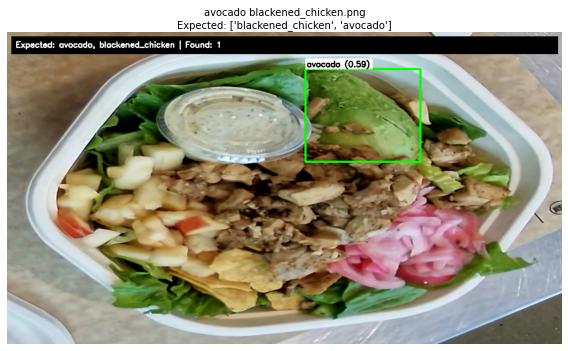


avocado blackened_chicken.png:
  Expected ingredients: ['blackened_chicken', 'avocado']
  Expected prompts: ['avocado', 'blackened_chicken']
  Detected labels: {'avocado'}
  Total detections: 1
--------------------------------------------------------------------------------


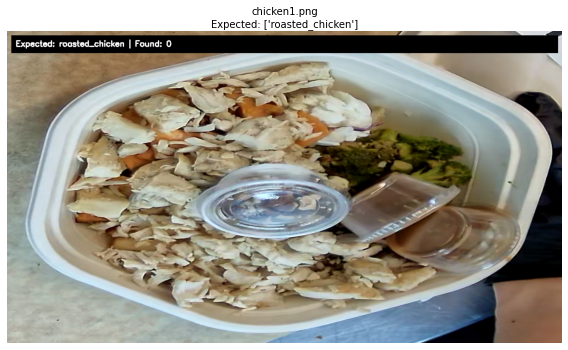


chicken1.png:
  Expected ingredients: ['roasted_chicken']
  Expected prompts: ['roasted_chicken']
  Detected labels: set()
  Total detections: 0
--------------------------------------------------------------------------------


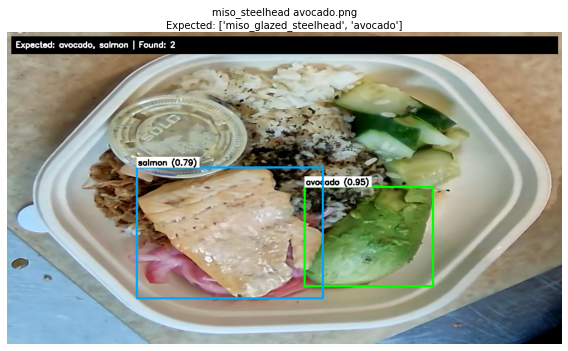


miso_steelhead avocado.png:
  Expected ingredients: ['miso_glazed_steelhead', 'avocado']
  Expected prompts: ['avocado', 'salmon']
  Detected labels: {'avocado', 'salmon'}
  Total detections: 2
--------------------------------------------------------------------------------


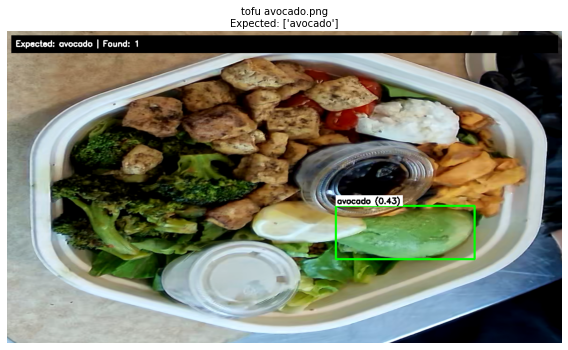


tofu avocado.png:
  Expected ingredients: ['avocado']
  Expected prompts: ['avocado']
  Detected labels: {'avocado'}
  Total detections: 1
--------------------------------------------------------------------------------


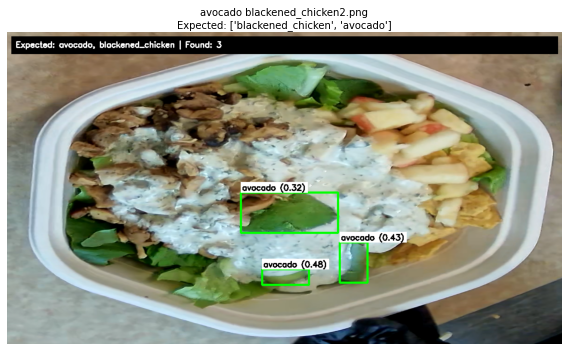


avocado blackened_chicken2.png:
  Expected ingredients: ['blackened_chicken', 'avocado']
  Expected prompts: ['avocado', 'blackened_chicken']
  Detected labels: {'avocado'}
  Total detections: 3
--------------------------------------------------------------------------------


In [14]:
def draw_detections(img, detections, expected_prompts):
    """Draw bounding boxes and labels on image."""
    img_copy = img.copy()
    
    # Color map for bounding boxes (BGR for OpenCV)
    label_colors_bgr = {
        "avocado": (0, 255, 0),           # Green
        "blackened_chicken": (255, 0, 0),  # Blue
        "roasted_chicken": (255, 0, 0),    # Blue
        "egg": (0, 255, 255),             # Yellow
        "steak": (0, 0, 255),             # Red
        "salmon": (255, 165, 0),          # Orange
        "roasted_tofu": (128, 0, 128),    # Purple
        "warm_portobello_mix": (255, 192, 203),  # Pink
    }
    default_color_bgr = (255, 255, 255)  # White for unknown
    
    # Draw bounding boxes
    for det in detections:
        label = det.get('label', 'unknown')
        box = det.get('box', [])
        score = det.get('score', 0.0)
        
        if len(box) == 4:
            x1, y1, x2, y2 = box
            color = label_colors_bgr.get(label.lower(), default_color_bgr)
            
            # Draw rectangle
            cv2.rectangle(img_copy, (x1, y1), (x2, y2), color, 3)
            
            # Add label with score
            label_text = f"{label} ({score:.2f})"
            
            (text_width, text_height), baseline = cv2.getTextSize(
                label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2
            )
            
            cv2.rectangle(img_copy, 
                         (x1, y1 - text_height - 10),
                         (x1 + text_width + 6, y1),
                         (255, 255, 255), -1)
            
            cv2.putText(img_copy, label_text, (x1 + 3, y1 - 5),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)
    
    # Add info text at the top
    h, w = img_copy.shape[:2]
    info_text = f"Expected: {', '.join(expected_prompts)} | Found: {len(detections)}"
    cv2.rectangle(img_copy, (10, 10), (w - 10, 50), (0, 0, 0), -1)
    cv2.putText(img_copy, info_text, (20, 35),
               cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
    
    return img_copy

# Visualize all results (small size for notebook - just for quick visualization)
for result in results:
    img_with_detections = draw_detections(
        result["image"], 
        result["detections"],
        result["expected_prompts"]
    )
    
    # Convert BGR to RGB for visualization
    img_rgb = cv2.cvtColor(img_with_detections, cv2.COLOR_BGR2RGB)
    
    # Display with small figure size to reduce notebook size
    plt.figure(figsize=(8, 6), dpi=72)  # Reduced from (16, 9) to (8, 6) and lower DPI
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"{result['path'].name}\nExpected: {result['expected_ingredients']}", 
              fontsize=10, pad=5)  # Reduced font size
    plt.tight_layout()
    plt.show()
    
    print(f"\n{result['path'].name}:")
    print(f"  Expected ingredients: {result['expected_ingredients']}")
    print(f"  Expected prompts: {result['expected_prompts']}")
    print(f"  Detected labels: {result['detected_labels']}")
    print(f"  Total detections: {len(result['detections'])}")
    print("-" * 80)


## Summary Statistics


In [15]:
# Calculate summary statistics
total_images = len(results)
total_detections = sum(len(r["detections"]) for r in results)

# Count matches (expected vs detected)
matches = 0
for result in results:
    expected_set = set(p.lower() for p in result["expected_prompts"])
    detected_set = set(d.lower() for d in result["detected_labels"])
    if expected_set.intersection(detected_set):
        matches += 1

print("=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)
print(f"Total images processed: {total_images}")
print(f"Total detections: {total_detections}")
print(f"Average detections per image: {total_detections / total_images if total_images > 0 else 0:.2f}")
print(f"Images with at least one match: {matches}/{total_images} ({100*matches/total_images if total_images > 0 else 0:.1f}%)")
print("\nDetailed results:")
print("-" * 80)

for result in results:
    expected_set = set(p.lower() for p in result["expected_prompts"])
    detected_set = set(d.lower() for d in result["detected_labels"])
    matched = expected_set.intersection(detected_set)
    missing = expected_set - detected_set
    extra = detected_set - expected_set
    
    status = "✓" if matched else "✗"
    print(f"{status} {result['path'].name}")
    print(f"    Expected: {result['expected_prompts']}")
    print(f"    Detected: {list(result['detected_labels'])}")
    if matched:
        print(f"    ✓ Matched: {list(matched)}")
    if missing:
        print(f"    ✗ Missing: {list(missing)}")
    if extra:
        print(f"    + Extra: {list(extra)}")
    print()


SUMMARY STATISTICS
Total images processed: 5
Total detections: 7
Average detections per image: 1.40
Images with at least one match: 4/5 (80.0%)

Detailed results:
--------------------------------------------------------------------------------
✓ avocado blackened_chicken.png
    Expected: ['avocado', 'blackened_chicken']
    Detected: ['avocado']
    ✓ Matched: ['avocado']
    ✗ Missing: ['blackened_chicken']

✗ chicken1.png
    Expected: ['roasted_chicken']
    Detected: []
    ✗ Missing: ['roasted_chicken']

✓ miso_steelhead avocado.png
    Expected: ['avocado', 'salmon']
    Detected: ['avocado', 'salmon']
    ✓ Matched: ['avocado', 'salmon']

✓ tofu avocado.png
    Expected: ['avocado']
    Detected: ['avocado']
    ✓ Matched: ['avocado']

✓ avocado blackened_chicken2.png
    Expected: ['avocado', 'blackened_chicken']
    Detected: ['avocado']
    ✓ Matched: ['avocado']
    ✗ Missing: ['blackened_chicken']

